In [1]:
import time
import torch
import numpy as np

import lightning.pytorch as pl
import matplotlib.pyplot as plt

from data import DatasetsConfig, SLRDatasetOLS
from models import ModelConfig, FinancialLSTM_MinVar, min_var_loss
from torch.utils.data import DataLoader, ConcatDataset

from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import (
    ModelCheckpoint, 
    LearningRateMonitor
)

# Data
data.py

In [2]:
datasets_cfg = DatasetsConfig(
    n_stock        = 10,
    n_windows      = 1000,
    lookback_window= 60,
    target_window  = 20,
    prediction_task= True,
    n_dataset_train= 70,
    n_dataset_val  = 20,
    n_dataset_test = 10
)

datasets = SLRDatasetOLS.generate_datasets(datasets_cfg)

# Model
models.py

In [3]:
model_cfg = ModelConfig(
    hidden_size    = 64,
    num_layers     = 2,
    dropout        = 0.2,
    learning_rate  = 1e-4,
    num_epochs     = 32,
    batch_size     = 1,
    shuffle_batches= True,
    lr_patience    = 4,
    loss_fn        = min_var_loss
)

model = FinancialLSTM_MinVar(model_cfg)

## Config

In [4]:
PATH = [
    'logs/financial_lstm', # Save dir
    'v8',                  # Name
    'prediction_run_MinVar=N_TRAIN=70__BATCH=1_EPOCH=16' # Version
]

## Datasets and DataLoaders

In [5]:
train_datasets, val_datasets, test_datasets = datasets

train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=model_cfg.batch_size, shuffle=model_cfg.shuffle_batches)
val_loader   = DataLoader(ConcatDataset(val_datasets), batch_size=model_cfg.batch_size, shuffle=False)
test_loader  = DataLoader(ConcatDataset(test_datasets),  batch_size=1, shuffle=False)

## Trainer

#### Logger

In [6]:
tb_logger = TensorBoardLogger(
    save_dir          = PATH[0],
    name              = PATH[1],
    version           = PATH[2],
    default_hp_metric = True
)

#### Callbacks

In [7]:
callbacks = [
    ModelCheckpoint(
        dirpath=f"{PATH[0]}/{PATH[1]}/{PATH[2]}/checkpoints",
        filename="best_{epoch:02d}_{val_loss:.6f}",
        monitor="val_loss",
        mode="min",
        save_last=True,
        auto_insert_metric_name=True
    ),
    
    LearningRateMonitor(
        logging_interval="epoch",
        log_momentum=False
    )
]

#### Trainer

In [8]:
trainer = pl.Trainer(
    max_epochs = model_cfg.num_epochs,
    logger     = tb_logger,
    callbacks  = callbacks,
    accelerator='cpu',
    devices='auto',
    log_every_n_steps=10,
    enable_progress_bar=True,
    enable_model_summary=True,
    gradient_clip_val=1.0
)

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/home/marko/Environments/python/fer/dipl/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


## Train model

In [9]:
# ==================== Train the Model ====================
print("\n" + "="*50)
print("Starting Training...")
print("="*50 + "\n")

trainer.fit(model, train_loader, val_loader)

# ==================== Print Results ====================
print("\n" + "="*50)
print("Training Complete!")
print("="*50)
print(f"Best model path: {trainer.checkpoint_callback.best_model_path}")
print(f"Best validation loss: {trainer.checkpoint_callback.best_model_score:.6f}")
print("="*50 + "\n")


  | Name         | Type    | Params | Mode 
-------------------------------------------------
0 | lstm         | LSTM    | 50.9 K | train
1 | alpha_head   | Linear  | 65     | train
2 | beta_head    | Linear  | 65     | train
3 | test_loss_fn | MSELoss | 0      | train
-------------------------------------------------
51.1 K    Trainable params
0         Non-trainable params
51.1 K    Total params
0.204     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode



Starting Training...



Sanity Checking: |                                                                                            …

/home/marko/Environments/python/fer/dipl/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/marko/Environments/python/fer/dipl/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |                                                                                                   …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=32` reached.



Training Complete!
Best model path: /home/marko/Workspace/FER/masters-thesis/logs/financial_lstm/v8/prediction_run_MinVar=N_TRAIN=70__BATCH=1_EPOCH=16/checkpoints/best_epoch=02_val_loss=0.000022.ckpt
Best validation loss: 0.000022



## Resume training

## Load model

# Benchmark

In [10]:
from data import add_intercept

true_alphas = torch.stack([test_dataset.alphas for test_dataset in test_datasets])
true_betas  = torch.stack([test_dataset.betas for test_dataset in test_datasets])

loss_function = torch.nn.MSELoss(reduction='mean')

model_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': [],
    'w': []
}

ols_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': [],
    'w': []
}

n_stock = datasets_cfg.n_stock
len_dataset = datasets_cfg.n_windows

start_time = time.time()
print("Evauating model on test set...")

model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        curr_dataset = i // len_dataset

        true_alpha = true_alphas[curr_dataset]
        true_beta  = true_betas[curr_dataset]

        r_context        = batch['r_context'].squeeze()
        r_market_context = batch['r_market_context'].squeeze()
        r_market_target  = batch['r_market_target'].squeeze()
        r_target         = batch['r_target'].squeeze()
        r_market_expanded = r_market_context.repeat(r_context.shape[0], 1)

        # Model loss
        _, (alpha, beta), w = model._shared_step(batch, i)
        reconstruction = alpha + beta * r_market_target
        
        model_summary['recon_loss'].append(loss_function(reconstruction, r_target).item())
        model_summary['alpha_loss'].append(loss_function(alpha, true_alpha).item())
        model_summary['beta_loss'].append(loss_function(beta, true_beta).item())

        model_summary['alpha'].append(alpha.detach())
        model_summary['beta'].append(beta.detach())
        model_summary['w'].append(w.detach())

        
        #OLS and OLS loss
        X = r_market_context
        Y = r_context.T
        
        X = add_intercept(X)
        
        # OLS
        OLS = torch.linalg.pinv(X.T @ X) @ (X.T @ Y)
        alpha = OLS[0, :].unsqueeze(1)
        beta  = OLS[1, :].unsqueeze(1)
        reconstruction = alpha.unsqueeze(-1) + beta.unsqueeze(-1) * r_market_target

        one = torch.ones(r_target.shape[0], 1)
        
        r_cov = r_context.cov()
        inv_r_cov = torch.linalg.pinv(r_cov)
        w = (inv_r_cov @ one) / (one.T @ inv_r_cov @ one)

        ols_summary['recon_loss'].append(loss_function(reconstruction, r_target).item())
        ols_summary['alpha_loss'].append(loss_function(alpha, true_alpha).item())
        ols_summary['beta_loss'].append(loss_function(beta, true_beta).item())

        ols_summary['alpha'].append(alpha)
        ols_summary['beta'].append(beta)
        ols_summary['w'].append(w)

"""
model_summary['alpha'] = torch.Tensor(model_summary['alpha']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)
model_summary['beta'] = torch.Tensor(model_summary['beta']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)

ols_summary['alpha'] = torch.Tensor(ols_summary['alpha']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)
ols_summary['beta'] = torch.Tensor(ols_summary['beta']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)
"""

print(f"Done! time = {time.time() - start_time:>7f} seconds")

Evauating model on test set...


/home/marko/Environments/python/fer/dipl/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([10, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/marko/Environments/python/fer/dipl/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([10, 20])) that is different to the input size (torch.Size([10, 1, 20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Done! time = 6.738307 seconds


In [14]:
from dataclasses import asdict

# Calculate test metrics for hp_metric
model_test_loss = np.mean(model_summary['recon_loss'])
ols_test_loss = np.mean(ols_summary['recon_loss'])

# Log hp_metric (model_test_loss)
tb_logger.log_hyperparams(
    params=asdict(model_cfg),
    metrics={'hp_metric': model_test_loss}
)

In [15]:
plt.figure(figsize=(10, 8))

plt.scatter(model_summary['recon_loss'], ols_summary['recon_loss'], marker='.')
plt.xlabel('Model Loss')
plt.ylabel('OLS Loss')

identity = np.linspace(min(ols_summary['recon_loss']), max(ols_summary['recon_loss']), 1000)
plt.plot(identity, identity, 'r--')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Reconstruction loss (MSE)', plt.gcf())

In [16]:
plt.figure(figsize=(10, 8))

plt.hist(model_summary['recon_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['recon_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_test_loss:.7f})')
plt.axvline(ols_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_test_loss:.7f})')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Reconstruction loss (MSE) Histogram', plt.gcf())

In [17]:
model_alpha_test_loss = np.mean(model_summary['alpha_loss'])
ols_alpha_test_loss = np.mean(ols_summary['alpha_loss'])

plt.figure(figsize=(10, 8))

plt.hist(model_summary['alpha_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['alpha_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_alpha_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_alpha_test_loss:.7f})')
plt.axvline(ols_alpha_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_alpha_test_loss:.7f})')

plt.title('Model vs OLS Alpha loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Alpha loss (MSE)', plt.gcf())

In [18]:
model_beta_test_loss = np.mean(model_summary['beta_loss'])
ols_beta_test_loss = np.mean(ols_summary['beta_loss'])

plt.figure(figsize=(10, 8))

plt.hist(model_summary['beta_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['beta_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_beta_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_beta_test_loss:.4f})')
plt.axvline(ols_beta_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_beta_test_loss:.4f})')

plt.title('Model vs OLS Beta loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Beta loss (MSE)', plt.gcf())

In [19]:
idxs = list(range(9))

model_summary['alpha'] = torch.stack(model_summary['alpha']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)
ols_summary['alpha'] = torch.stack(ols_summary['alpha']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)

model_summary['beta'] = torch.stack(model_summary['beta']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)
ols_summary['beta'] = torch.stack(ols_summary['beta']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)

In [20]:
fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Model vs OLS Alpha estimation')

axs = axs.flatten()

for ax, idx in zip(axs, idxs):
    dataset_idx = idx
    
    true_alpha  = true_alphas[dataset_idx, 0]
    model_alpha = model_summary['alpha'][dataset_idx, :, 0]
    ols_alpha   = ols_summary['alpha'][dataset_idx, :, 0]

    sample = np.arange(len(model_alpha))

    ax.set_title(f'Dataset {idx}, Stock 0')
    ax.scatter(sample, model_alpha, label='Model', marker='.')
    ax.scatter(sample, ols_alpha, label='OLS', marker='.')
    ax.axhline(true_alpha, color='magenta', linestyle='--', label='True alpha')

    ax.legend()
    ax.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Alpha estimation', fig)

In [21]:
fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Model vs OLS Beta estimation')

axs = axs.flatten()

for ax, idx in zip(axs, idxs):
    dataset_idx = idx
    
    true_beta  = true_betas[dataset_idx, 0]
    model_beta = model_summary['beta'][dataset_idx, :, 0]
    ols_beta   = ols_summary['beta'][dataset_idx, :, 0]

    sample = np.arange(len(model_beta))

    ax.set_title(f'Dataset {idx}, Stock 0')
    ax.scatter(sample, model_beta, label='Model', marker='.')
    ax.scatter(sample, ols_beta, label='OLS', marker='.')
    ax.axhline(true_beta, color='magenta', linestyle='--', label='True beta')

    ax.legend()
    ax.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Beta estimation', fig)

In [22]:
fig = plt.figure(figsize=(10, 8))
plt.hist(model_summary['beta'].flatten(), bins=500)
plt.title('Model beta distribution')

plt.grid()
tb_logger.experiment.add_figure('Model Beta Distribution', fig)

In [23]:
idxs = list(range(datasets_cfg.n_stock * datasets_cfg.n_dataset_test))
n = datasets_cfg.n_windows

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Ground Truth Beta vs Estimated Beta')

identity = np.linspace(true_betas.min(), true_betas.max(), 1000)

# Top subplot - Model
ax1.set_title('LSTM Model')
ax1.set_ylabel('Model Beta')
ax1.plot(identity, identity, color='magenta', linestyle='--')
ax1.grid()

# Bottom subplot - OLS
ax2.set_title('OLS')
ax2.set_xlabel('Ground Truth Beta')
ax2.set_ylabel('OLS Beta ')
ax2.plot(identity, identity, color='magenta', linestyle='--')
ax2.grid()

for idx in idxs:
    stock_idx   = idx % datasets_cfg.n_stock
    dataset_idx = idx // n
    
    true_beta  = true_betas[dataset_idx, stock_idx]
    model_beta = model_summary['beta'][dataset_idx, :, stock_idx]
    ols_beta   = ols_summary['beta'][dataset_idx, :, stock_idx]

    x = [true_beta] * n

    ax1.scatter(x, model_beta, marker='.', alpha=0.1)
    ax2.scatter(x, ols_beta, marker='.', alpha=0.1)

tb_logger.experiment.add_figure('Ground Truth Beta vs Estimated Beta', fig)

In [24]:
idxs = list(range(datasets_cfg.n_stock * datasets_cfg.n_dataset_test))
n = datasets_cfg.n_windows

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Ground Truth Alpha vs Estimated Alpha')

identity = np.linspace(true_alphas.min(), true_alphas.max(), 1000)

# Top subplot - Model
ax1.set_title('LSTM Model')
ax1.set_ylabel('Model Alpha')
ax1.plot(identity, identity, color='magenta', linestyle='--')
ax1.grid()

# Bottom subplot - OLS
ax2.set_title('OLS')
ax2.set_xlabel('Ground Truth Alpha')
ax2.set_ylabel('OLS Alpha ')
ax2.plot(identity, identity, color='magenta', linestyle='--')
ax2.grid()

for idx in idxs:
    stock_idx   = idx % datasets_cfg.n_stock
    dataset_idx = idx // n
    
    true_alpha  = true_alphas[dataset_idx, stock_idx]
    model_alpha = model_summary['alpha'][dataset_idx, :, stock_idx]
    ols_alpha   = ols_summary['alpha'][dataset_idx, :, stock_idx]

    x = [true_alpha] * n

    ax1.scatter(x, model_alpha, marker='.', alpha=0.1)
    ax2.scatter(x, ols_alpha, marker='.', alpha=0.1)

tb_logger.experiment.add_figure('Ground Truth Alpha vs Estimated Alpha', fig)

In [25]:
tb_logger.save()

In [38]:
r = test_datasets[0].returns[:, :80]

In [39]:
r.shape

torch.Size([10, 80])

In [65]:
torch.ones(10, 1) * 0.1

tensor([[0.1000],
        [0.1000],
        [0.1000],
        [0.1000],
        [0.1000],
        [0.1000],
        [0.1000],
        [0.1000],
        [0.1000],
        [0.1000]])

In [42]:
p = model_summary['w'][0].T @ r
p.shape

torch.Size([1, 80])

In [58]:
pi = p.squeeze().cumsum(0).exp()

In [59]:
pi

tensor([0.9971, 0.9948, 0.9916, 0.9901, 0.9930, 0.9972, 0.9958, 0.9962, 0.9968,
        0.9971, 0.9905, 0.9953, 0.9947, 0.9963, 0.9934, 0.9915, 0.9881, 0.9883,
        0.9893, 0.9923, 0.9899, 0.9860, 0.9862, 0.9913, 0.9870, 0.9888, 0.9890,
        0.9913, 0.9935, 0.9979, 0.9974, 1.0020, 1.0011, 0.9969, 0.9969, 0.9971,
        0.9954, 0.9942, 0.9955, 0.9946, 0.9875, 0.9878, 0.9896, 0.9901, 0.9916,
        0.9872, 0.9845, 0.9799, 0.9805, 0.9804, 0.9815, 0.9808, 0.9808, 0.9753,
        0.9784, 0.9789, 0.9760, 0.9789, 0.9784, 0.9807, 0.9826, 0.9858, 0.9857,
        0.9885, 0.9887, 0.9887, 0.9815, 0.9785, 0.9798, 0.9804, 0.9790, 0.9795,
        0.9781, 0.9770, 0.9731, 0.9735, 0.9737, 0.9748, 0.9782, 0.9802])

KeyboardInterrupt: 

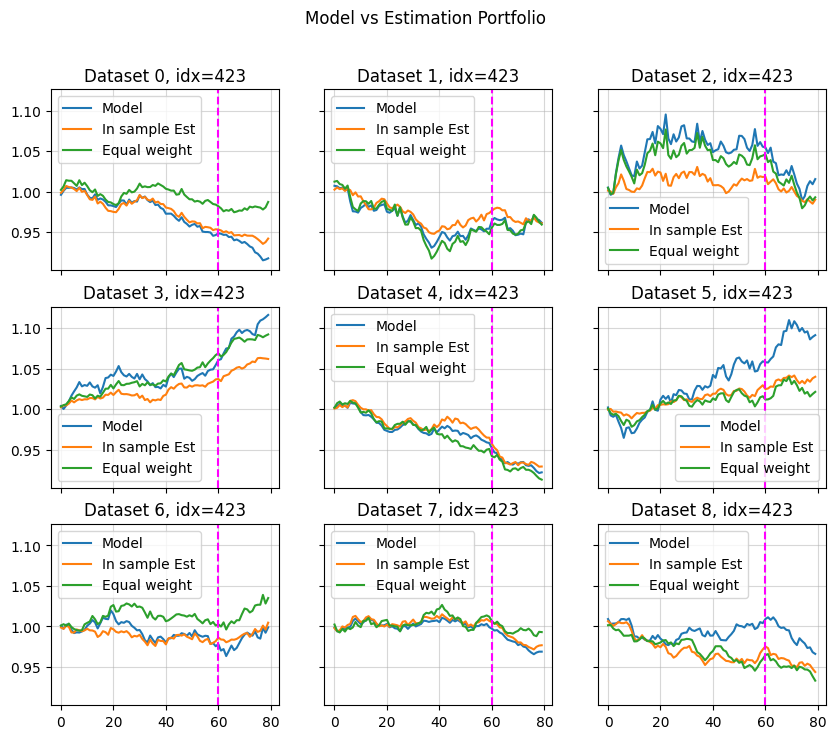

In [72]:
ew = torch.ones(10, 1) * 0.1
for k in range(datasets_cfg.n_windows):
    fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
    fig.suptitle('Model vs Estimation Portfolio')
    
    axs = axs.flatten()
    
    for ax, idx in zip(axs, idxs):
        dataset = test_datasets[idx]
        r = dataset.returns[:, 80:160]
        
        model_w = model_summary['w'][idx * 1000 + k]
        ols_w   = ols_summary['w'][idx * 1000 + k]
    
        model_p = model_w.T @ r
        ols_p   = ols_w.T @ r
        ew_p    = ew.T @ r
    
        model_pi = model_p.squeeze().cumsum(0).exp()
        ols_pi   = ols_p.squeeze().cumsum(0).exp()
        ew_pi    = ew_p.squeeze().cumsum(0).exp()
    
        sample = np.arange(len(model_pi))
    
        ax.set_title(f'Dataset {idx}, idx={k}')
        ax.plot(sample, model_pi, label='Model')
        ax.plot(sample, ols_pi, label='In sample Est')
        ax.plot(sample, ew_pi, label='Equal weight')
        ax.axvline(60, color='magenta', linestyle='--')
    
        ax.legend()
        ax.grid(alpha=0.5)
    
    # Log to TensorBoard
    tb_logger.experiment.add_figure('Model vs Estimation Portfolio', fig, global_step=k)